## Sentiment Analysis — Baseline Model (TF-IDF)
### Dataset: Yelp Academic Dataset (1800k reviews, 3-class balanced)
### Approach: TF-IDF feature extraction + Naive Bayes, Logistic Regression, SVM
### Goal: Establish a strong baseline before moving to GloVe embeddings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score)

# paths
PROC_PATH  = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\data\processed"
MODELS_DIR = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\models"
FIGURES    = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\figures"

os.makedirs(MODELS_DIR, exist_ok=True)

LABELS     = ['Negative', 'Neutral', 'Positive']
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nithilan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Nithilan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Nithilan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 1. Load Processed Data

In [2]:
df = pd.read_csv(os.path.join(PROC_PATH, 'reviews_sampled.csv'))

# drop duplicates
df = df.drop_duplicates(subset='text').reset_index(drop=True)

print(f"Shape     : {df.shape}")
print(f"Classes   : {df['sentiment'].value_counts().to_dict()}")
df.head()

Shape     : (1798400, 4)
Classes   : {'Positive': 599765, 'Negative': 599393, 'Neutral': 599242}


,text,stars,sentiment,label
0,Drove one and half hour there. Waited for an h...,1.0,Negative,0
1,So I gave this place a bad review the first ti...,1.0,Negative,0
2,Flowers looked good. They dropped them off hou...,2.0,Negative,0
3,As I sit here I am watching the cook wipe the ...,1.0,Negative,0
4,This is not another Patron review made by many...,1.0,Negative,0


## 2. Preprocessing Pipeline
Steps:
- Lowercase
- Remove punctuation and noise
- Tokenize
- Remove stopwords
- Lemmatize

In [3]:
import re

def preprocess(text):
    # lowercase
    text = str(text).lower()
    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # tokenize
    tokens = text.split()
    # remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print("Preprocessing... (this will take a few minutes on 1800k reviews)")
df['clean_text'] = df['text'].apply(preprocess)

# save cleaned data
df[['clean_text', 'sentiment', 'label']].to_csv(
    os.path.join(PROC_PATH, 'reviews_clean.csv'), index=False
)
print("Done. Saved → reviews_clean.csv")
df[['text', 'clean_text', 'sentiment']].head(3)

Preprocessing... (this will take a few minutes on 1800k reviews)
Done. Saved → reviews_clean.csv


,text,clean_text,sentiment
0,Drove one and half hour there. Waited for an h...,drove one half hour waited hour long expected ...,Negative
1,So I gave this place a bad review the first ti...,gave place bad review first time havent back t...,Negative
2,Flowers looked good. They dropped them off hou...,flower looked good dropped hour like worried c...,Negative


## 3. Train / Test Split
80% train, 20% test — stratified to preserve class balance

In [4]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"\nTrain class balance:\n{y_train.value_counts().sort_index()}")

Train size : 1,438,720
Test size  : 359,680

Train class balance:
label
0    479514
1    479394
2    479812
Name: count, dtype: int64


## 4. TF-IDF Feature Extraction
- Unigrams + Bigrams (ngram_range 1,2)
- Max 50,000 features
- Sublinear TF scaling for better performance on long reviews

In [5]:
print("Fitting TF-IDF vectorizer...")

vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Feature matrix shape : {X_train_tfidf.shape}")

# save vectorizer
joblib.dump(vectorizer, os.path.join(MODELS_DIR, 'tfidf_vectorizer.joblib'))
print("Saved → tfidf_vectorizer.joblib")

Fitting TF-IDF vectorizer...
Feature matrix shape : (1438720, 50000)
Saved → tfidf_vectorizer.joblib


## 5. Train & Evaluate All Models
Helper function to train, evaluate, and plot confusion matrix for each model

In [6]:
results = {}

def train_evaluate(name, model, X_tr, X_te, y_tr, y_te):
    print(f"\n{'='*50}")
    print(f"Training : {name}")
    print('='*50)
    
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    f1    = f1_score(y_te, preds, average='weighted')
    
    print(classification_report(y_te, preds, target_names=LABELS))
    
    # confusion matrix
    cm  = confusion_matrix(y_te, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    fname = f"confusion_matrix_tfidf_{name.lower().replace(' ', '_')}.png"
    plt.savefig(os.path.join(FIGURES, fname), dpi=150)
    plt.show()
    print(f"Saved → {fname}")
    
    results[name] = {'model': model, 'f1': round(f1, 4)}
    return model

### 5a. Naive Bayes


Training : Naive Bayes
              precision    recall  f1-score   support

    Negative       0.77      0.75      0.76    119879
     Neutral       0.64      0.72      0.68    119848
    Positive       0.86      0.78      0.82    119953

    accuracy                           0.75    359680
   macro avg       0.76      0.75      0.75    359680
weighted avg       0.76      0.75      0.75    359680



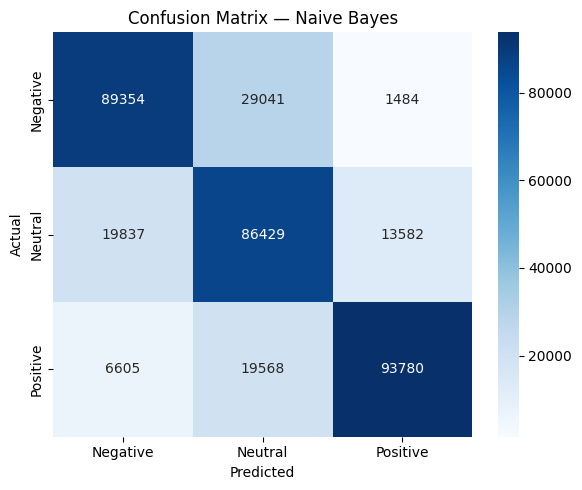

Saved → confusion_matrix_tfidf_naive_bayes.png


In [7]:
nb_model = train_evaluate(
    'Naive Bayes',
    MultinomialNB(alpha=0.1),
    X_train_tfidf, X_test_tfidf,
    y_train, y_test
)

### 5b. Logistic Regression


Training : Logistic Regression
              precision    recall  f1-score   support

    Negative       0.83      0.83      0.83    119879
     Neutral       0.72      0.72      0.72    119848
    Positive       0.85      0.85      0.85    119953

    accuracy                           0.80    359680
   macro avg       0.80      0.80      0.80    359680
weighted avg       0.80      0.80      0.80    359680



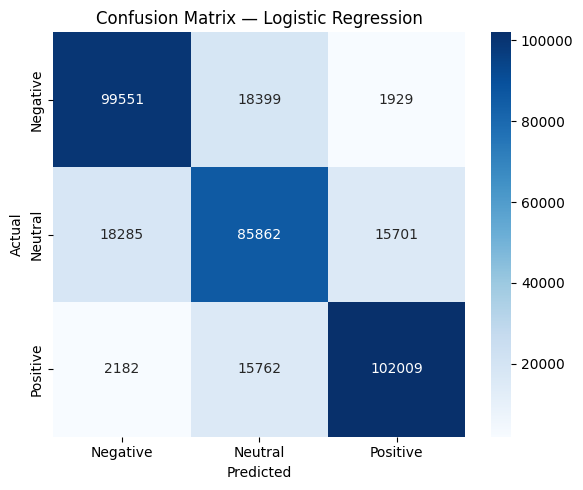

Saved → confusion_matrix_tfidf_logistic_regression.png


In [8]:
lr_model = train_evaluate(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    X_train_tfidf, X_test_tfidf,
    y_train, y_test
)

### 5c. Linear SVM


Training : Linear SVM
              precision    recall  f1-score   support

    Negative       0.82      0.84      0.83    119879
     Neutral       0.72      0.69      0.71    119848
    Positive       0.85      0.86      0.85    119953

    accuracy                           0.80    359680
   macro avg       0.80      0.80      0.80    359680
weighted avg       0.80      0.80      0.80    359680



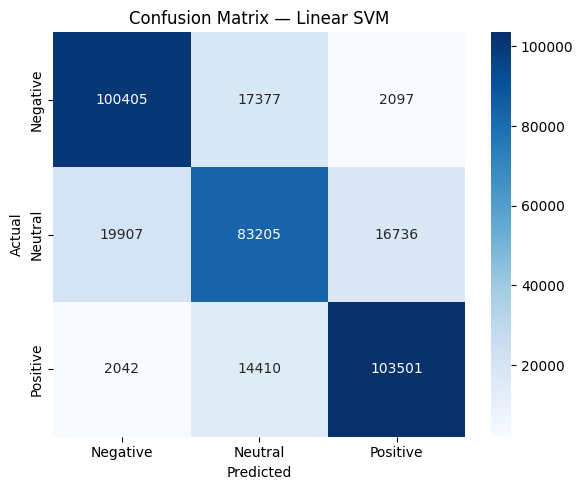

Saved → confusion_matrix_tfidf_linear_svm.png


In [9]:
svm_model = train_evaluate(
    'Linear SVM',
    LinearSVC(C=1.0, max_iter=2000, random_state=42),
    X_train_tfidf, X_test_tfidf,
    y_train, y_test
)

## 6. Model Comparison

              Model  Weighted F1
Logistic Regression       0.7991
         Linear SVM       0.7973
        Naive Bayes       0.7521


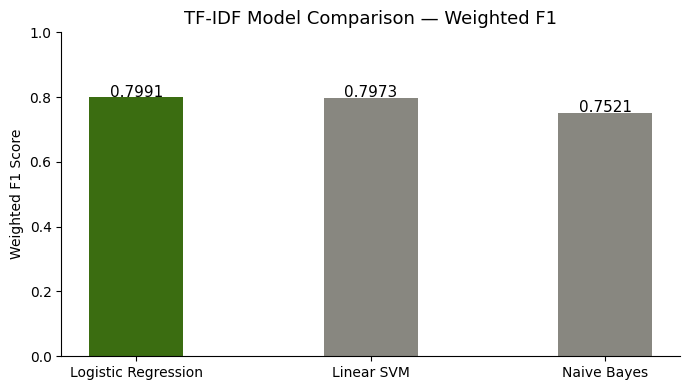

Saved → reports/tfidf_results.csv


In [10]:
comparison = pd.DataFrame([
    {'Model': name, 'Weighted F1': info['f1']}
    for name, info in results.items()
]).sort_values('Weighted F1', ascending=False).reset_index(drop=True)

print(comparison.to_string(index=False))

# plot
fig, ax = plt.subplots(figsize=(7, 4))
colors  = ['#3B6D11' if i == 0 else '#888780' for i in range(len(comparison))]
bars    = ax.bar(comparison['Model'], comparison['Weighted F1'], color=colors, width=0.4)

for bar, val in zip(bars, comparison['Weighted F1']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            str(val), ha='center', fontsize=11)

ax.set_title('TF-IDF Model Comparison — Weighted F1', fontsize=13)
ax.set_ylabel('Weighted F1 Score')
ax.set_ylim(0, 1.0)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'tfidf_model_comparison.png'), dpi=150)
plt.show()

# save comparison to reports
comparison.to_csv(
    r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\tfidf_results.csv",
    index=False
)
print("Saved → reports/tfidf_results.csv")

## 7. Save Best Model

In [11]:
best_name  = comparison.iloc[0]['Model']
best_model = results[best_name]['model']
best_f1    = comparison.iloc[0]['Weighted F1']

joblib.dump(best_model, os.path.join(MODELS_DIR, 'tfidf_best_model.joblib'))

print(f"Best model : {best_name}")
print(f"Weighted F1: {best_f1}")
print(f"Saved → models/tfidf_best_model.joblib")

Best model : Logistic Regression
Weighted F1: 0.7991
Saved → models/tfidf_best_model.joblib


## 8. Top Influential Features Per Class
Words that most strongly drive each sentiment prediction

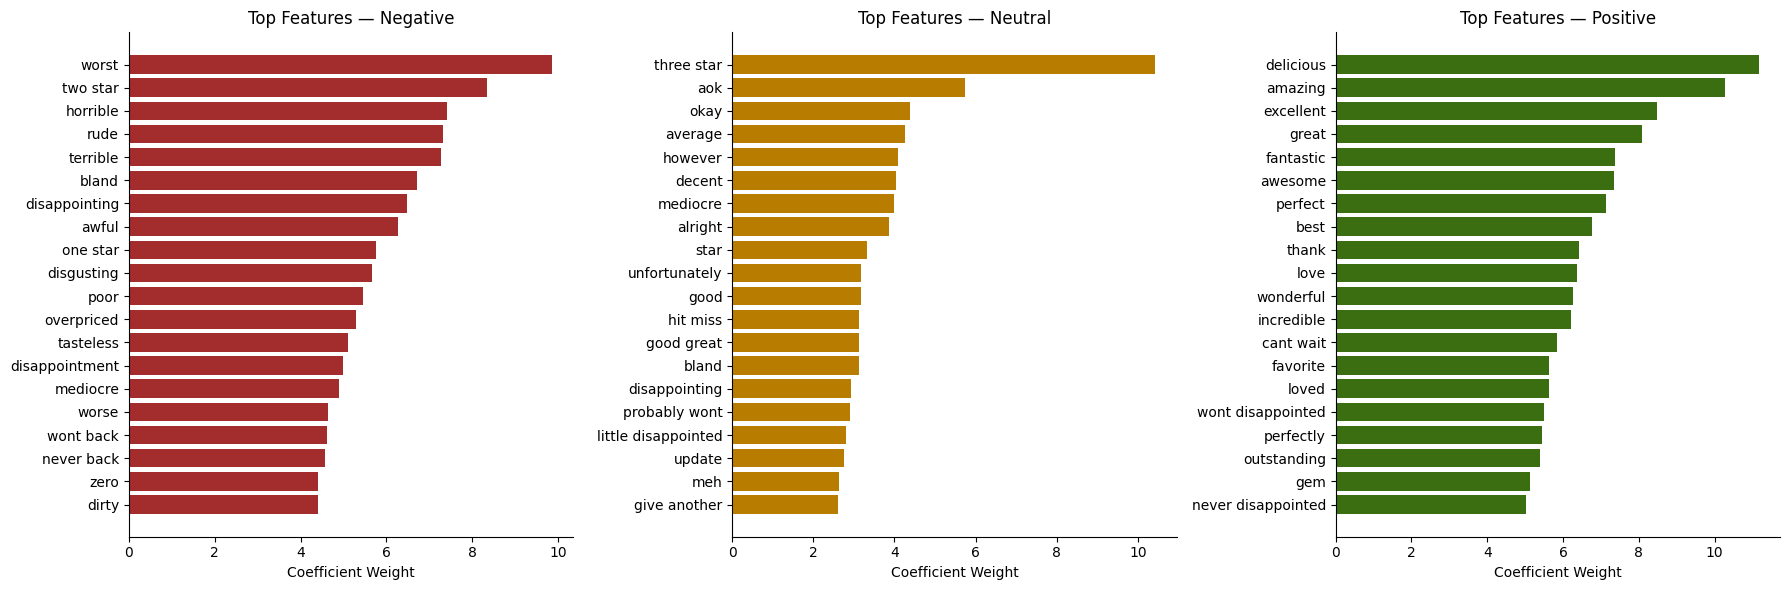

Saved → top_features_tfidf.png


In [12]:
# only works for Logistic Regression
feature_names = vectorizer.get_feature_names_out()
coefs         = lr_model.coef_

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (ax, label) in enumerate(zip(axes, LABELS)):
    top_idx    = np.argsort(coefs[i])[-20:]
    top_words  = feature_names[top_idx]
    top_scores = coefs[i][top_idx]
    
    colors = ['#3B6D11' if label == 'Positive'
              else '#A32D2D' if label == 'Negative'
              else '#B87D00']* len(top_words)
    
    ax.barh(top_words, top_scores, color=colors[0])
    ax.set_title(f'Top Features — {label}', fontsize=12)
    ax.set_xlabel('Coefficient Weight')
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'top_features_tfidf.png'), dpi=150)
plt.show()
print("Saved → top_features_tfidf.png")

## 9. Baseline Summary

| Model | Weighted F1 |
|---|---|
| Naive Bayes | 0.7498 |
| Logistic Regression | 0.7979 |
| Linear SVM | 0.7856 |

- Best baseline model: **TBD after run**
- TF-IDF with unigrams + bigrams captures word patterns well
- Neutral class is hardest to classify (expected — most ambiguous)
- Next step: improve with GloVe word embeddings → 03_glove.ipynb